In [35]:

import somJ.config as config
from functions import *
from somJ.som import SoM

import gc
import numpy as np
import pandas as pd
import time
import tracemalloc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import trustworthiness
import umap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
def evaluate_embedding(X, X_embedded, n_neighbors=5):
    trust = trustworthiness(X, X_embedded, n_neighbors=n_neighbors)
    cont = compute_continuity(X, X_embedded, n_neighbors=n_neighbors)
    return trust, cont


In [37]:
def evaluate_all(datasets, eval_subset_size=30000,n_neighbors=5, random_state=42, n_splits=5):
    all_results = []

    for name in datasets:
        print(f"\nDataset: {name}")
        X, y = load_dataset(name)
        print(f"tamaño dataset: {len(X)}")
      
        # X, y = load_dataset(name)

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        method_names = ['PCA', 'LDA', 'UMAP', 't-SNE', 'SOM']
        results_by_method = {k: [] for k in method_names}

        for fold, (train_idx, _) in enumerate(skf.split(X, y), 1):
            X_train, y_train = X[train_idx], y[train_idx]
            print(f" Fold {fold}/{n_splits} Tamaño fold:{len(X_train)}")

            if len(X_train) > eval_subset_size:
                print(f"fold corregido:{len(X_train)} -> {eval_subset_size}")
                np.random.seed(random_state)
                idx_total = np.random.choice(len(X_train), eval_subset_size, replace=False)
                X_train, y_train = X_train[idx_total], y_train[idx_total]

            # PCA
            gc.collect()
            tracemalloc.start()
            t0 = time.perf_counter()
            pca_emb = PCA(n_components=2, random_state=random_state).fit_transform(X_train)
            t = time.perf_counter() - t0
            current, peak = tracemalloc.get_traced_memory()
            mem = peak / 1e6  # Convertir a MB
            tracemalloc.stop()
            gc.collect()
            trust, cont = evaluate_embedding(X_train, pca_emb, n_neighbors)
            results_by_method['PCA'].append({"dataset": name, "method": 'PCA', "fold": fold, "tiempo (s)": t, "memoria (Mb)": mem, "trust": trust, "continuity": cont})

            # LDA
            gc.collect()
            tracemalloc.start()
            t0 = time.perf_counter()
            lda_emb = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_train, y_train)
            t = time.perf_counter() - t0
            current, peak = tracemalloc.get_traced_memory()
            mem = peak / 1e6  # Convertir a MB
            tracemalloc.stop()
            gc.collect()
            trust, cont = evaluate_embedding(X_train, lda_emb, n_neighbors)
            results_by_method['LDA'].append({"dataset": name, "method": 'LDA', "fold": fold, "tiempo (s)": t, "memoria (Mb)": mem, "trust": trust, "continuity": cont})

            # UMAP
            gc.collect()
            tracemalloc.start()
            t0 = time.perf_counter()
            umap_emb = umap.UMAP(n_components=2, random_state=random_state).fit_transform(X_train)
            t = time.perf_counter() - t0
            current, peak = tracemalloc.get_traced_memory()
            mem = peak / 1e6  # Convertir a MB
            tracemalloc.stop()
            gc.collect()
            trust, cont = evaluate_embedding(X_train, umap_emb, n_neighbors)
            results_by_method['UMAP'].append({"dataset": name, "method": 'UMAP', "fold": fold, "tiempo (s)": t, "memoria (Mb)": mem, "trust": trust, "continuity": cont})

            # t-SNE
            gc.collect()
            tracemalloc.start()
            t0 = time.perf_counter()
            tsne_emb = TSNE(n_components=2, random_state=random_state, perplexity=30).fit_transform(X_train)
            t = time.perf_counter() - t0
            current, peak = tracemalloc.get_traced_memory()
            mem = peak / 1e6  # Convertir a MB
            tracemalloc.stop()
            gc.collect()
            trust, cont = evaluate_embedding(X_train, tsne_emb, n_neighbors)
            results_by_method['t-SNE'].append({"dataset": name, "method": 't-SNE', "fold": fold, "tiempo (s)": t, "memoria (Mb)": mem, "trust": trust, "continuity": cont})

            # SOM
            gc.collect()
            tracemalloc.start()
            t0 = time.perf_counter()
            som = SoM(method=config.INIT_METHOD, data=X_train[:1000], total_nodes=config.TOTAL_NODES)
            som.train(train_data=X_train)
            som_emb = som.find_all_winner(X_train)
            t = time.perf_counter() - t0
            current, peak = tracemalloc.get_traced_memory()
            mem = peak / 1e6  # Convertir a MB
            tracemalloc.stop()
            gc.collect()
            trust, cont = evaluate_embedding(X_train, som_emb, n_neighbors)
            results_by_method['SOM'].append({"dataset": name, "method": 'SOM', "fold": fold, "tiempo (s)": t, "memoria (Mb)": mem, "trust": trust, "continuity": cont})

        # Agregamos media y desviación por método
        for method_name, records in results_by_method.items():
            df_method = pd.DataFrame(records)
            stats = df_method[["tiempo (s)", "memoria (Mb)", "trust", "continuity"]].agg(['mean', 'std']).T
            stats.columns = ['mean', 'std']
            stats["method"] = method_name
            stats["dataset"] = name
            all_results.append(stats.reset_index())

    df_results = pd.concat(all_results, ignore_index=True)
    return df_results


In [38]:
datasets = [
            'Iris', 
            'Digits', 
            'MNIST', 'Fashion MNIST']

df_results = evaluate_all(datasets)


Dataset: Iris
tamaño dataset: 150
 Fold 1/5 Tamaño fold:120
 Fold 2/5 Tamaño fold:120
 Fold 3/5 Tamaño fold:120
 Fold 4/5 Tamaño fold:120
 Fold 5/5 Tamaño fold:120

Dataset: Digits
tamaño dataset: 1797
 Fold 1/5 Tamaño fold:1437
 Fold 2/5 Tamaño fold:1437
 Fold 3/5 Tamaño fold:1438
 Fold 4/5 Tamaño fold:1438
 Fold 5/5 Tamaño fold:1438

Dataset: MNIST
tamaño dataset: 60000
 Fold 1/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 2/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 3/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 4/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 5/5 Tamaño fold:48000
fold corregido:48000 -> 30000

Dataset: Fashion MNIST
tamaño dataset: 60000
 Fold 1/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 2/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 3/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 4/5 Tamaño fold:48000
fold corregido:48000 -> 30000
 Fold 5/5 Tamaño fold:48000
fold corregido:48000 -> 3000

In [39]:

print("\n Resultados por Dataset y Método:")
print(df_results)

# Guardar también los promedios
df_results.to_csv("resultados_topologia.csv", index=False)

print("\n Resultadosguardados como CSV")


# Graficos -------------------------------------------------------------------------




 Resultados por Dataset y Método:
           index       mean       std method        dataset
0     tiempo (s)   0.001380  0.000096    PCA           Iris
1   memoria (Mb)   0.011999  0.000711    PCA           Iris
2          trust   0.978509  0.002096    PCA           Iris
3     continuity   0.656667  0.022761    PCA           Iris
4     tiempo (s)   0.002522  0.000084    LDA           Iris
..           ...        ...       ...    ...            ...
75    continuity   0.379072  0.000980  t-SNE  Fashion MNIST
76    tiempo (s)  10.932087  0.717847    SOM  Fashion MNIST
77  memoria (Mb)  99.571448  0.092646    SOM  Fashion MNIST
78         trust   0.967489  0.001116    SOM  Fashion MNIST
79    continuity   0.011773  0.000514    SOM  Fashion MNIST

[80 rows x 5 columns]

 Resultadosguardados como CSV


In [40]:
df_results

,index,mean,std,method,dataset
0,tiempo (s),0.001380,0.000096,PCA,Iris
1,memoria (Mb),0.011999,0.000711,PCA,Iris
2,trust,0.978509,0.002096,PCA,Iris
3,continuity,0.656667,0.022761,PCA,Iris
4,tiempo (s),0.002522,0.000084,LDA,Iris
...,...,...,...,...,...
75,continuity,0.379072,0.000980,t-SNE,Fashion MNIST
76,tiempo (s),10.932087,0.717847,SOM,Fashion MNIST
77,memoria (Mb),99.571448,0.092646,SOM,Fashion MNIST
78,trust,0.967489,0.001116,SOM,Fashion MNIST


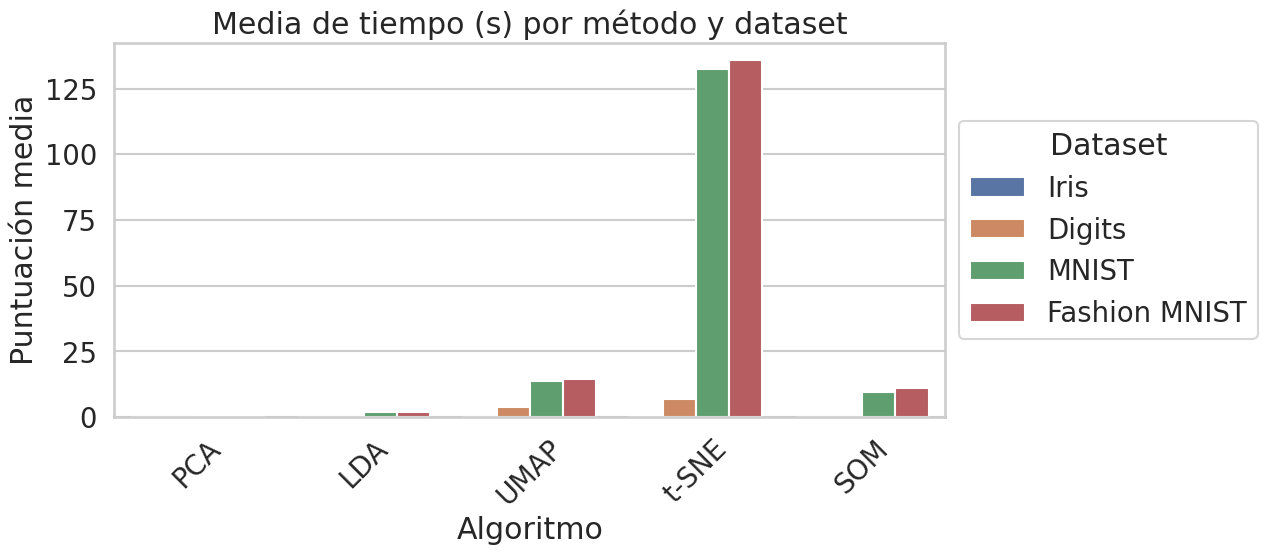

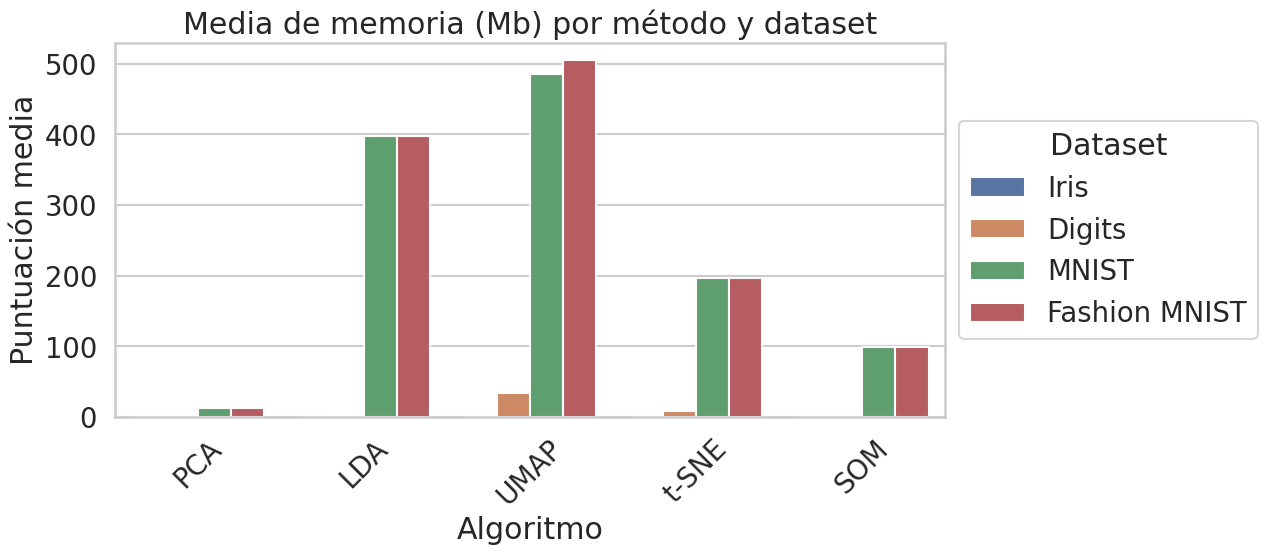

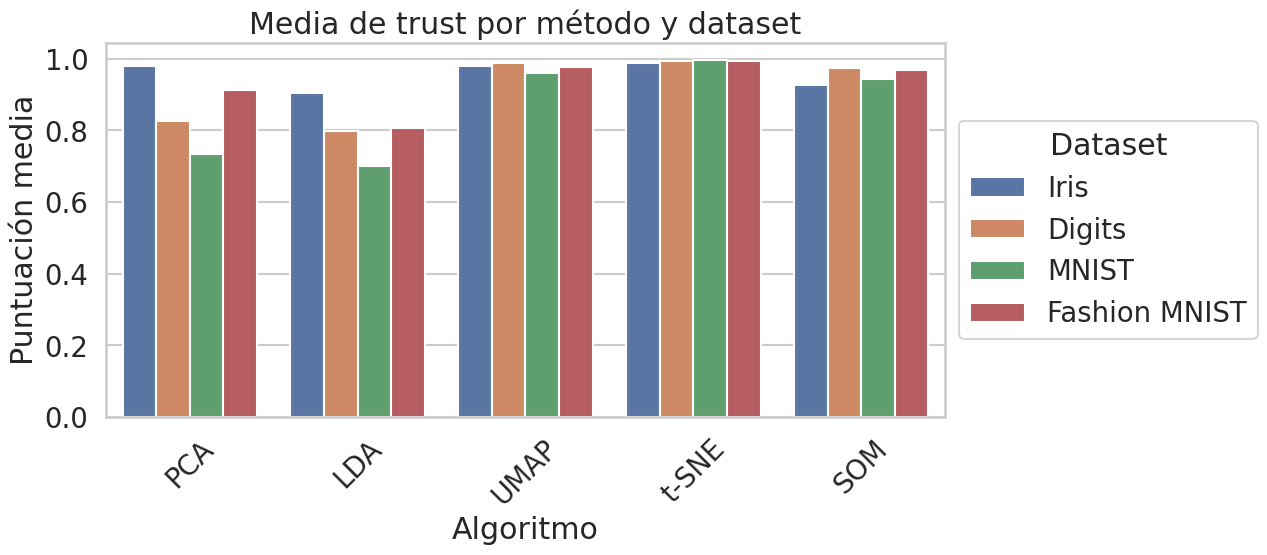

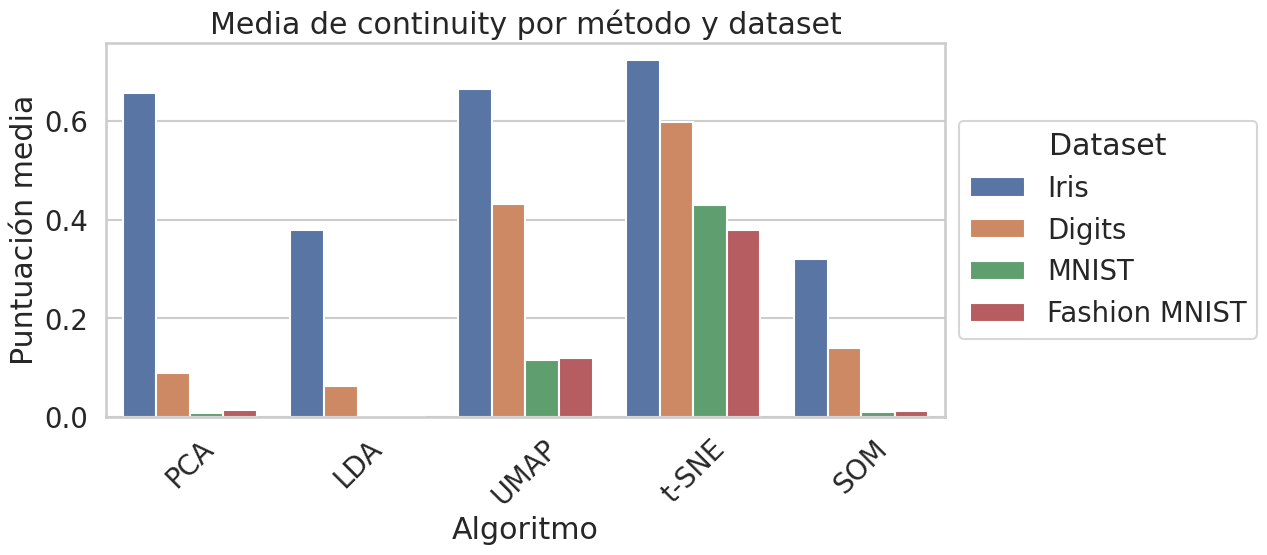

In [48]:
metricas = df_results['index'].unique()
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
for metrica in metricas:
    df_metrica = df_results[df_results['index'] == metrica]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_metrica, x='method', y='mean', hue='dataset')
    
    plt.title(f'Media de {metrica} por método y dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.xlabel("Algoritmo")
    plt.ylabel("Puntuación media")
    # Mover la leyenda fuera de la gráfica
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Dataset')
    plt.savefig(f"g_top/metricas/datasets_{metrica}.png", dpi= 300, bbox_inches='tight')
    plt.show()